## Two-Step Implementation of the $X$ Gate

In this notebook, we explore an alternative implementation of the $X$ gate using a two-step protocol:

1. **First Pulse:** Drive the qubit from the ground state $\lvert 0 \rangle$ to the superposition state $\frac{1}{\sqrt{2}}(\lvert 0 \rangle + \lvert 1 \rangle)$.
2. **Second Pulse:** Drive the qubit from the superposition state to the excited state $\lvert 1 \rangle$.

This sequence effectively realizes an $X$ gate through intermediate rotation steps on the Bloch sphere. We implement this using:

- **Gaussian pulses**
- **DRAG pulses**
  




--- Simulating Two Sequential and CORRECTED Gaussian π/2-Pulses ---
    Pulse 1: |0>  -->  (|0> + i|1>)/sqrt(2)   (Populations -> 0.5)
    Pulse 2: (|0> + i|1>)/sqrt(2)  -->  |1>   (Population |1> -> 1.0)


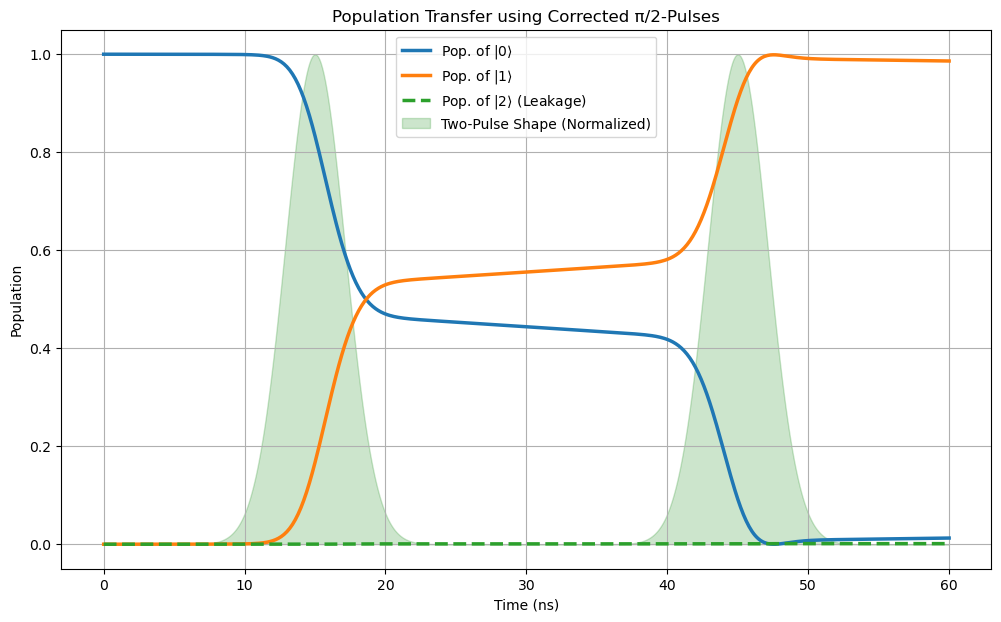

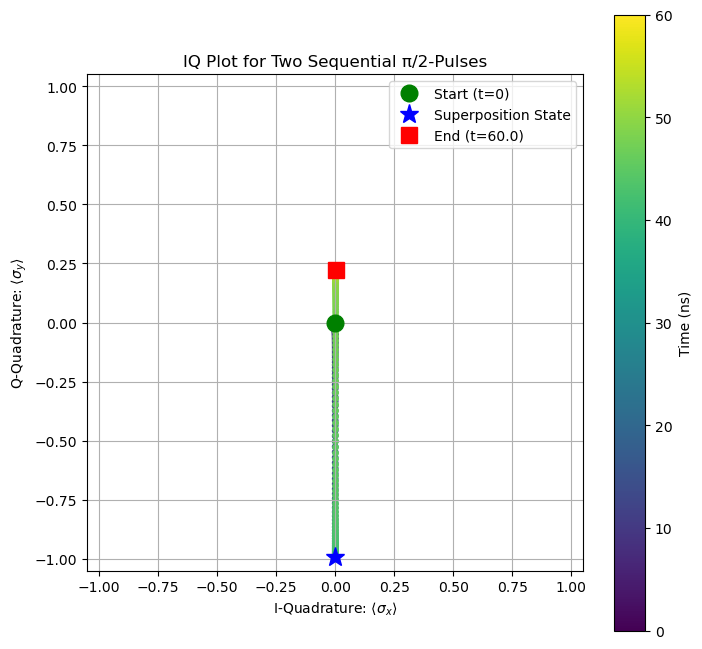


--- Generating Experimental Readout IQ Plot (with Blobs) ---
Final State: 1.3% |0>, 98.6% |1>, 0.1% |2>


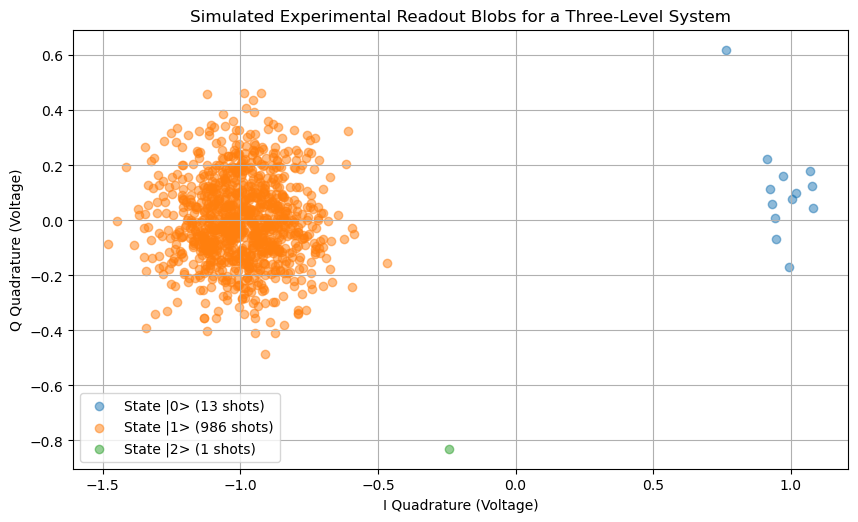

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (
    tensor, qeye, destroy, basis, mesolve, coherent
)

# ==============================================================================
# EXPERIMENTAL READOUT PLOT FUNCTION (UNCHANGED)
# ==============================================================================
def generate_readout_blobs(p0_final, p1_final, p2_final, num_shots=1000, noise_level=0.15):
    """
    Simulates an experimental IQ readout for a three-level system by generating
    noisy data points based on the final probabilities of being in states
    |0>, |1>, or |2>.
    """
    # Renormalize to handle small numerical errors
    total_prob = p0_final + p1_final + p2_final
    if not np.isclose(total_prob, 1.0):
        p0_final /= total_prob
        p1_final /= total_prob
        p2_final /= total_prob

    print("\n--- Generating Experimental Readout IQ Plot (with Blobs) ---")
    print(f"Final State: {p0_final*100:.1f}% |0>, {p1_final*100:.1f}% |1>, {p2_final*100:.1f}% |2>")

    center_0 = np.array([1.0, 0.1])
    center_1 = np.array([-1.0, 0.0])
    center_2 = np.array([0.0, -1.0])

    num_shots_0 = int(np.round(p0_final * num_shots))
    num_shots_1 = int(np.round(p1_final * num_shots))
    num_shots_2 = num_shots - num_shots_0 - num_shots_1

    blob_0_I = np.random.normal(loc=center_0[0], scale=noise_level, size=num_shots_0)
    blob_0_Q = np.random.normal(loc=center_0[1], scale=noise_level, size=num_shots_0)
    blob_1_I = np.random.normal(loc=center_1[0], scale=noise_level, size=num_shots_1)
    blob_1_Q = np.random.normal(loc=center_1[1], scale=noise_level, size=num_shots_1)
    blob_2_I = np.random.normal(loc=center_2[0], scale=noise_level, size=num_shots_2)
    blob_2_Q = np.random.normal(loc=center_2[1], scale=noise_level, size=num_shots_2)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(blob_0_I, blob_0_Q, alpha=0.5, label=f'State |0> ({num_shots_0} shots)')
    ax.scatter(blob_1_I, blob_1_Q, alpha=0.5, label=f'State |1> ({num_shots_1} shots)')
    ax.scatter(blob_2_I, blob_2_Q, alpha=0.5, label=f'State |2> ({num_shots_2} shots)')
    ax.set_title("Simulated Experimental Readout Blobs for a Three-Level System")
    ax.set_xlabel("I Quadrature (Voltage)"), ax.set_ylabel("Q Quadrature (Voltage)")
    ax.grid(True), ax.legend(), ax.set_aspect('equal', adjustable='box')
    plt.show()


# ==============================================================================
# SIMULATION WITH CORRECTED π/2-PULSES
# ==============================================================================
def simulate_two_gaussian_pulses():
    """
    Demonstrates a two-step state transfer: |0> -> Superposition -> |1>
    using two sequential Gaussian pi/2-pulses with the CORRECT pulse area.
    """
    print("--- Simulating Two Sequential and CORRECTED Gaussian π/2-Pulses ---")
    print("    Pulse 1: |0>  -->  (|0> + i|1>)/sqrt(2)   (Populations -> 0.5)")
    print("    Pulse 2: (|0> + i|1>)/sqrt(2)  -->  |1>   (Population |1> -> 1.0)")


    # --- 1. SETUP: System parameters (EXACTLY THE SAME) ---
    N_atom = 3
    N_field = 4
    w_b1 = 5.0 * 2 * np.pi
    w_b2 = 5.0 * 2 * np.pi
    w_a = 5.05 * 2 * np.pi
    Omega1, Omega2 = 5.0 * 2 * np.pi, 4.99 * 2 * np.pi
    lambda1, lambda2, g_12 = 0.03 * 2 * np.pi, 0.03 * 2 * np.pi, 0.0003 * 2 * np.pi

    # --- 2. Define Operators (UNCHANGED) ---
    a_bare = destroy(N_field)
    sm_ab1_bare = basis(N_atom, 0) * basis(N_atom, 2).dag()
    sm_ab2_bare = basis(N_atom, 1) * basis(N_atom, 2).dag()
    sm_01_bare = basis(N_atom, 0) * basis(N_atom, 1).dag()
    a1 = tensor(qeye(N_atom), a_bare, qeye(N_field))
    a2 = tensor(qeye(N_atom), qeye(N_field), a_bare)
    sm_ab1 = tensor(sm_ab1_bare, qeye(N_field), qeye(N_field))
    sm_ab2 = tensor(sm_ab2_bare, qeye(N_field), qeye(N_field))
    sm_01 = tensor(sm_01_bare, qeye(N_field), qeye(N_field))
    P_a = tensor(basis(N_atom, 2).proj(), qeye(N_field), qeye(N_field))
    P_b1 = tensor(basis(N_atom, 0).proj(), qeye(N_field), qeye(N_field))
    P_b2 = tensor(basis(N_atom, 1).proj(), qeye(N_field), qeye(N_field))
    I_op = tensor(sm_01_bare + sm_01_bare.dag(), qeye(N_field), qeye(N_field))
    Q_op = tensor(-1j * sm_01_bare + 1j * sm_01_bare.dag(), qeye(N_field), qeye(N_field))

    # --- 3. Construct the Original, Unchanged Hamiltonian ---
    H_atom = w_a * P_a + w_b1 * P_b1 + w_b2 * P_b2
    H_fields = Omega1 * a1.dag() * a1 + Omega2 * a2.dag() * a2
    H_interaction = lambda1 * (a1.dag() * sm_ab1 + a1 * sm_ab1.dag()) + \
                    lambda2 * (a2.dag() * sm_ab2 + a2 * sm_ab2.dag())  + \
                    g_12 * (sm_01 + sm_01.dag())
    H_static_quantum = H_atom + H_fields + H_interaction

    # --- 4. Define TWO SEQUENTIAL GAUSSIAN π/2-Pulses (with corrected area) ---
    pulse1_t0 = 15.0
    pulse2_t0 = 45.0
    pulse_duration = 5
    pulse_sigma = pulse_duration / (2 * np.sqrt(2 * np.log(2)))

    # <-- THE ONLY CHANGE IS HERE
    # To create a 50/50 superposition (a pi/2 GATE), the required pulse AREA is pi/4.
    # The previous value (pi/2) was creating a full population transfer (a pi GATE).
    required_area = np.pi / 4.0
    pulse_amplitude = required_area / (pulse_sigma * np.sqrt(2 * np.pi))

    H_drive_01_op = sm_01 + sm_01.dag()
    H_drive_02_op = sm_ab2 + sm_ab2.dag()

    def two_pulse_coeff(t, args):
        pulse1 = args['A'] * np.exp(-(t - args['t0_1'])**2 / (2 * args['sigma']**2))
        pulse2 = args['A'] * np.exp(-(t - args['t0_2'])**2 / (2 * args['sigma']**2))
        return pulse1 + pulse2

    drive_args = {'A': pulse_amplitude, 't0_1': pulse1_t0, 't0_2': pulse2_t0, 'sigma': pulse_sigma}
    unwanted_drive_amp_ratio = 0.1

    H_final = [H_static_quantum,
               [H_drive_01_op, two_pulse_coeff],
               [H_drive_02_op, lambda t, args: unwanted_drive_amp_ratio * two_pulse_coeff(t, args)]
              ]

    # --- 5. Initial State and Simulation (UNCHANGED) ---
    psi0 = tensor(basis(N_atom, 0), coherent(N_field, 0), coherent(N_field, 0))
    c_ops = []
    tlist = np.linspace(0, 60.0, 601)
    e_ops = [P_b1, P_b2, P_a, I_op, Q_op]
    result = mesolve(H_final, psi0, tlist, c_ops, e_ops, args=drive_args)

    # --- 6. Data Extraction and Plotting (UNCHANGED) ---
    pop_0, pop_1, pop_2 = result.expect[0], result.expect[1], result.expect[2]
    I_vals, Q_vals = result.expect[3], result.expect[4]

    fig_p, ax_p = plt.subplots(figsize=(12, 7))
    ax_p.plot(tlist, pop_0, lw=2.5, label=r'Pop. of $|0\rangle$')
    ax_p.plot(tlist, pop_1, lw=2.5, label=r'Pop. of $|1\rangle$')
    ax_p.plot(tlist, pop_2, lw=2.5, label=r'Pop. of $|2\rangle$ (Leakage)', linestyle='--')
    pulse_shape_norm = [two_pulse_coeff(t, drive_args) / pulse_amplitude for t in tlist]
    ax_p.fill_between(tlist, 0, pulse_shape_norm, color='green', alpha=0.2, label='Two-Pulse Shape (Normalized)')
    ax_p.set_title("Population Transfer using Corrected π/2-Pulses")
    ax_p.set_xlabel("Time (ns)"), ax_p.set_ylabel("Population"), ax_p.legend(), ax_p.grid(True)
    ax_p.set_ylim(-0.05, 1.05)
    plt.show()

    fig_iq, ax_iq = plt.subplots(figsize=(8, 8))
    points = ax_iq.scatter(I_vals, Q_vals, c=tlist, cmap='viridis', s=15)
    plt.colorbar(points, ax=ax_iq, label='Time (ns)')
    ax_iq.plot(I_vals[0], Q_vals[0], 'go', markersize=12, label='Start (t=0)')
    mid_time_index = np.argmin(np.abs(tlist - (pulse1_t0 + pulse2_t0) / 2))
    ax_iq.plot(I_vals[mid_time_index], Q_vals[mid_time_index], 'b*', markersize=14, label='Superposition State')
    ax_iq.plot(I_vals[-1], Q_vals[-1], 'rs', markersize=12, label=f'End (t={tlist[-1]})')
    ax_iq.set_title(r"IQ Plot for Two Sequential π/2-Pulses")
    ax_iq.set_xlabel(r"I-Quadrature: $\langle\sigma_x\rangle$")
    ax_iq.set_ylabel(r"Q-Quadrature: $\langle\sigma_y\rangle$")
    ax_iq.grid(True), ax_iq.set_aspect('equal', adjustable='box'), ax_iq.set_xlim(-1.05, 1.05), ax_iq.set_ylim(-1.05, 1.05), ax_iq.legend()
    plt.show()

    generate_readout_blobs(pop_0[-1], pop_1[-1], pop_2[-1])


if __name__ == '__main__':
    simulate_two_gaussian_pulses()

--- Simulating Two Sequential DRAG π/2-Pulses ---
    Pulse 1: |0>  -->  (|0> + i|1>)/sqrt(2)   (Populations -> 0.5)
    Pulse 2: (|0> + i|1>)/sqrt(2)  -->  |1>   (Population |1> -> 1.0)


C:\Users\HP\anaconda3\lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


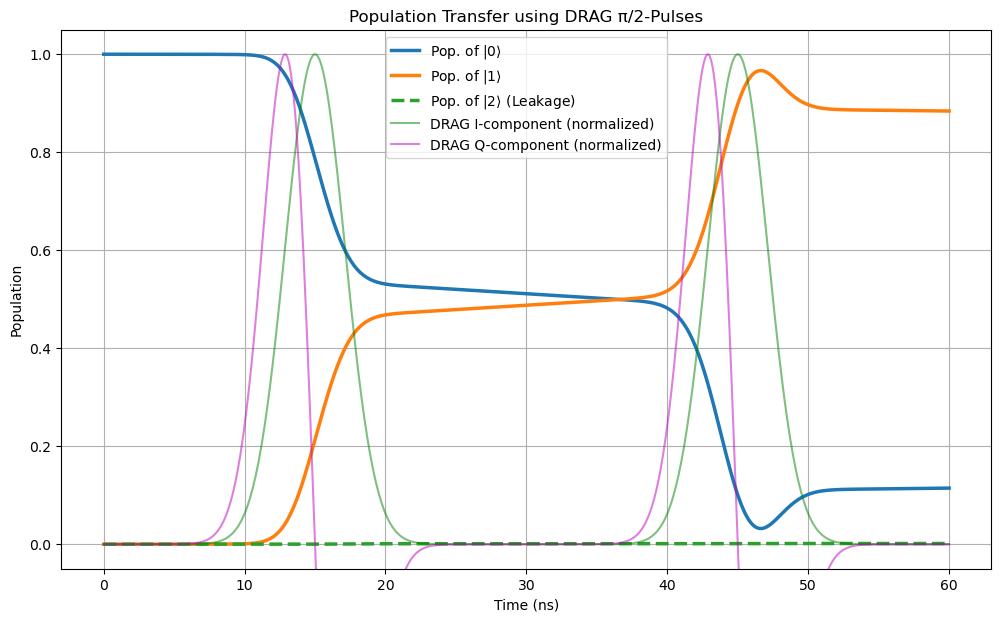

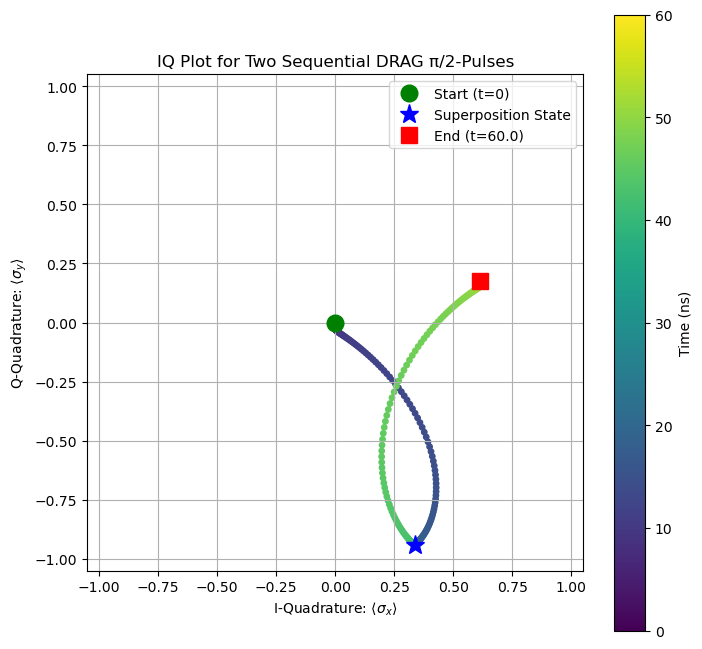


--- Generating Experimental Readout IQ Plot (with Blobs) ---
Final State: 11.4% |0>, 88.4% |1>, 0.1% |2>


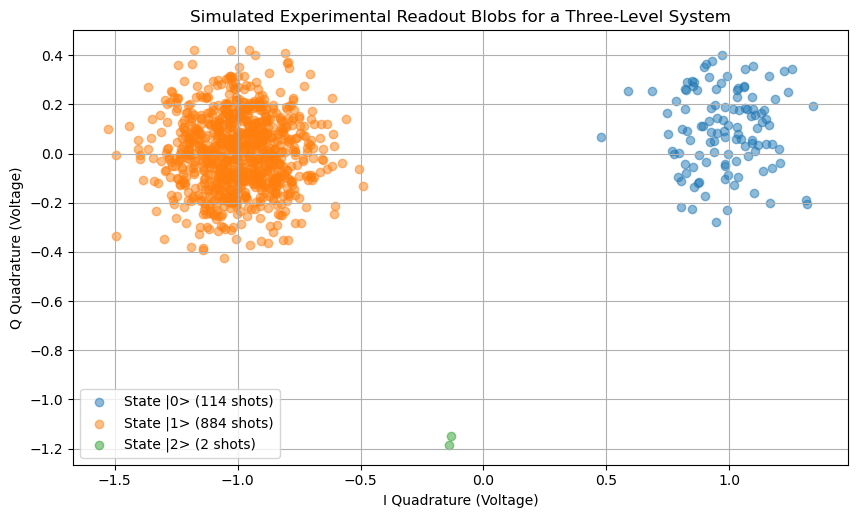

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (
    tensor, qeye, destroy, basis, mesolve, coherent
)

# ==============================================================================
# EXPERIMENTAL READOUT PLOT FUNCTION (UNCHANGED)
# ==============================================================================
def generate_readout_blobs(p0_final, p1_final, p2_final, num_shots=1000, noise_level=0.15):
    """
    Simulates an experimental IQ readout for a three-level system by generating
    noisy data points based on the final probabilities of being in states
    |0>, |1>, or |2>.
    """
    # Renormalize to handle small numerical errors
    total_prob = p0_final + p1_final + p2_final
    if not np.isclose(total_prob, 1.0):
        p0_final /= total_prob
        p1_final /= total_prob
        p2_final /= total_prob

    print("\n--- Generating Experimental Readout IQ Plot (with Blobs) ---")
    print(f"Final State: {p0_final*100:.1f}% |0>, {p1_final*100:.1f}% |1>, {p2_final*100:.1f}% |2>")

    center_0 = np.array([1.0, 0.1])
    center_1 = np.array([-1.0, 0.0])
    center_2 = np.array([0.0, -1.0])

    num_shots_0 = int(np.round(p0_final * num_shots))
    num_shots_1 = int(np.round(p1_final * num_shots))
    num_shots_2 = num_shots - num_shots_0 - num_shots_1

    blob_0_I = np.random.normal(loc=center_0[0], scale=noise_level, size=num_shots_0)
    blob_0_Q = np.random.normal(loc=center_0[1], scale=noise_level, size=num_shots_0)
    blob_1_I = np.random.normal(loc=center_1[0], scale=noise_level, size=num_shots_1)
    blob_1_Q = np.random.normal(loc=center_1[1], scale=noise_level, size=num_shots_1)
    blob_2_I = np.random.normal(loc=center_2[0], scale=noise_level, size=num_shots_2)
    blob_2_Q = np.random.normal(loc=center_2[1], scale=noise_level, size=num_shots_2)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(blob_0_I, blob_0_Q, alpha=0.5, label=f'State |0> ({num_shots_0} shots)')
    ax.scatter(blob_1_I, blob_1_Q, alpha=0.5, label=f'State |1> ({num_shots_1} shots)')
    ax.scatter(blob_2_I, blob_2_Q, alpha=0.5, label=f'State |2> ({num_shots_2} shots)')
    ax.set_title("Simulated Experimental Readout Blobs for a Three-Level System")
    ax.set_xlabel("I Quadrature (Voltage)"), ax.set_ylabel("Q Quadrature (Voltage)")
    ax.grid(True), ax.legend(), ax.set_aspect('equal', adjustable='box')
    plt.show()


# ==============================================================================
# SIMULATION WITH DRAG PULSES
# ==============================================================================
def simulate_two_drag_pulses():
    """
    Demonstrates a two-step state transfer: |0> -> Superposition -> |1>
    using two sequential DRAG π/2-pulses.
    """
    print("--- Simulating Two Sequential DRAG π/2-Pulses ---")
    print("    Pulse 1: |0>  -->  (|0> + i|1>)/sqrt(2)   (Populations -> 0.5)")
    print("    Pulse 2: (|0> + i|1>)/sqrt(2)  -->  |1>   (Population |1> -> 1.0)")

    # --- 1. SETUP: System parameters ---
    N_atom = 3  # Three-level system (|0>, |1>, |2>)
    N_field = 4
    w_b1 = 5.0 * 2 * np.pi
    w_b2 = 5.0 * 2 * np.pi
    w_a = 5.05 * 2 * np.pi  # |2> state energy
    Omega1, Omega2 = 5.0 * 2 * np.pi, 4.99 * 2 * np.pi
    lambda1, lambda2, g_12 = 0.03 * 2 * np.pi, 0.03 * 2 * np.pi, 0.0003 * 2 * np.pi
    
    # Anharmonicity (important for DRAG)
    alpha = w_a - (w_b1 + w_b2)/2  # |2> - (|0> + |1>)/2

    # --- 2. Define Operators ---
    a_bare = destroy(N_field)
    sm_ab1_bare = basis(N_atom, 0) * basis(N_atom, 2).dag()
    sm_ab2_bare = basis(N_atom, 1) * basis(N_atom, 2).dag()
    sm_01_bare = basis(N_atom, 0) * basis(N_atom, 1).dag()
    a1 = tensor(qeye(N_atom), a_bare, qeye(N_field))
    a2 = tensor(qeye(N_atom), qeye(N_field), a_bare)
    sm_ab1 = tensor(sm_ab1_bare, qeye(N_field), qeye(N_field))
    sm_ab2 = tensor(sm_ab2_bare, qeye(N_field), qeye(N_field))
    sm_01 = tensor(sm_01_bare, qeye(N_field), qeye(N_field))
    P_a = tensor(basis(N_atom, 2).proj(), qeye(N_field), qeye(N_field))
    P_b1 = tensor(basis(N_atom, 0).proj(), qeye(N_field), qeye(N_field))
    P_b2 = tensor(basis(N_atom, 1).proj(), qeye(N_field), qeye(N_field))
    I_op = tensor(sm_01_bare + sm_01_bare.dag(), qeye(N_field), qeye(N_field))
    Q_op = tensor(-1j * sm_01_bare + 1j * sm_01_bare.dag(), qeye(N_field), qeye(N_field))
    
    # Define the operator for unwanted drive to |2> state
    H_drive_02_op = sm_ab2 + sm_ab2.dag()  # This was missing in the previous version

    # --- 3. Construct the Hamiltonian ---
    H_atom = w_a * P_a + w_b1 * P_b1 + w_b2 * P_b2
    H_fields = Omega1 * a1.dag() * a1 + Omega2 * a2.dag() * a2
    H_interaction = lambda1 * (a1.dag() * sm_ab1 + a1 * sm_ab1.dag()) + \
                    lambda2 * (a2.dag() * sm_ab2 + a2 * sm_ab2.dag())  + \
                    g_12 * (sm_01 + sm_01.dag())
    H_static_quantum = H_atom + H_fields + H_interaction

    # --- 4. Define TWO SEQUENTIAL DRAG PULSES ---
    pulse1_t0 = 15.0
    pulse2_t0 = 45.0
    pulse_duration = 5
    pulse_sigma = pulse_duration / (2 * np.sqrt(2 * np.log(2)))
    
    # For DRAG pulses, we need both I and Q components
    required_area = np.pi / 4.0  # For π/2 pulse
    pulse_amplitude = required_area / (pulse_sigma * np.sqrt(2 * np.pi))
    
    # DRAG parameter (β) - optimal value is typically 1/(2*anharmonicity)
    beta = 1/(2*alpha) if alpha != 0 else 0

    H_drive_I = sm_01 + sm_01.dag()  # I component (σ_x)
    H_drive_Q = -1j * (sm_01 - sm_01.dag())  # Q component (σ_y)

    def drag_pulse_I(t, args):
        """I component of DRAG pulse (Gaussian envelope)"""
        pulse1 = args['A'] * np.exp(-(t - args['t0_1'])**2 / (2 * args['sigma']**2))
        pulse2 = args['A'] * np.exp(-(t - args['t0_2'])**2 / (2 * args['sigma']**2))
        return pulse1 + pulse2

    def drag_pulse_Q(t, args):
        """Q component of DRAG pulse (derivative of Gaussian)"""
        pulse1 = -args['beta'] * args['A'] * (t - args['t0_1']) * np.exp(-(t - args['t0_1'])**2 / (2 * args['sigma']**2)) / args['sigma']**2
        pulse2 = -args['beta'] * args['A'] * (t - args['t0_2']) * np.exp(-(t - args['t0_2'])**2 / (2 * args['sigma']**2)) / args['sigma']**2
        return pulse1 + pulse2

    drive_args = {
        'A': pulse_amplitude, 
        't0_1': pulse1_t0, 
        't0_2': pulse2_t0, 
        'sigma': pulse_sigma,
        'beta': beta
    }

    # Small unwanted drive to |2> state (to test DRAG's leakage suppression)
    unwanted_drive_amp_ratio = 0.1

    H_final = [
        H_static_quantum,
        [H_drive_I, drag_pulse_I],  # I component
        [H_drive_Q, drag_pulse_Q],  # Q component
        [H_drive_02_op, lambda t, args: unwanted_drive_amp_ratio * drag_pulse_I(t, args)]
    ]

    # --- 5. Initial State and Simulation ---
    psi0 = tensor(basis(N_atom, 0), coherent(N_field, 0), coherent(N_field, 0))
    c_ops = []
    tlist = np.linspace(0, 60.0, 601)
    e_ops = [P_b1, P_b2, P_a, I_op, Q_op]
    result = mesolve(H_final, psi0, tlist, c_ops, e_ops, args=drive_args)

    # --- 6. Data Extraction and Plotting ---
    pop_0, pop_1, pop_2 = result.expect[0], result.expect[1], result.expect[2]
    I_vals, Q_vals = result.expect[3], result.expect[4]

    # Plot populations
    fig_p, ax_p = plt.subplots(figsize=(12, 7))
    ax_p.plot(tlist, pop_0, lw=2.5, label=r'Pop. of $|0\rangle$')
    ax_p.plot(tlist, pop_1, lw=2.5, label=r'Pop. of $|1\rangle$')
    ax_p.plot(tlist, pop_2, lw=2.5, label=r'Pop. of $|2\rangle$ (Leakage)', linestyle='--')
    
    # Plot pulse shapes (I and Q components)
    pulse_I = [drag_pulse_I(t, drive_args) for t in tlist]
    pulse_Q = [drag_pulse_Q(t, drive_args) for t in tlist]
    ax_p.plot(tlist, pulse_I/np.max(pulse_I), 'g-', alpha=0.5, label='DRAG I-component (normalized)')
    ax_p.plot(tlist, pulse_Q/np.max(pulse_Q), 'm-', alpha=0.5, label='DRAG Q-component (normalized)')
    
    ax_p.set_title("Population Transfer using DRAG π/2-Pulses")
    ax_p.set_xlabel("Time (ns)"), ax_p.set_ylabel("Population"), ax_p.legend(), ax_p.grid(True)
    ax_p.set_ylim(-0.05, 1.05)
    plt.show()

    # Plot IQ trajectory
    fig_iq, ax_iq = plt.subplots(figsize=(8, 8))
    points = ax_iq.scatter(I_vals, Q_vals, c=tlist, cmap='viridis', s=15)
    plt.colorbar(points, ax=ax_iq, label='Time (ns)')
    ax_iq.plot(I_vals[0], Q_vals[0], 'go', markersize=12, label='Start (t=0)')
    mid_time_index = np.argmin(np.abs(tlist - (pulse1_t0 + pulse2_t0) / 2))
    ax_iq.plot(I_vals[mid_time_index], Q_vals[mid_time_index], 'b*', markersize=14, label='Superposition State')
    ax_iq.plot(I_vals[-1], Q_vals[-1], 'rs', markersize=12, label=f'End (t={tlist[-1]})')
    ax_iq.set_title(r"IQ Plot for Two Sequential DRAG π/2-Pulses")
    ax_iq.set_xlabel(r"I-Quadrature: $\langle\sigma_x\rangle$")
    ax_iq.set_ylabel(r"Q-Quadrature: $\langle\sigma_y\rangle$")
    ax_iq.grid(True), ax_iq.set_aspect('equal', adjustable='box'), ax_iq.set_xlim(-1.05, 1.05), ax_iq.set_ylim(-1.05, 1.05), ax_iq.legend()
    plt.show()

    generate_readout_blobs(pop_0[-1], pop_1[-1], pop_2[-1])


if __name__ == '__main__':
    simulate_two_drag_pulses()